# CPS Enrollment — Clean Data Analysis & Feature Engineering (Basic)

**Input:** `fact_enrollment_annualized_clean` (Fabric Lakehouse)  
**Output:** `ml_enrollment_feature_table` — one row per school × grade × year  

---

### Core Logic

Enrollment in **Grade G, Year Y** is driven by two things:
1. **SAME_GRADE_LAST_YEAR** — how many were in this grade at this school last year  
2. **FEEDER_GRADE_LAST_YEAR** — how many were in grade G-1 last year (they advance into G)  

Special cases handled automatically:
- Grade 1 ← K (last year)
- Grade 10 ← 9 (last year)
- K and 9 are **excluded from targets** but kept as feeder data

---
## 1. Setup & Load

In [1]:
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.sql.window import Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titleweight"] = "bold"

print("✔ Imports complete")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 3, Finished, Available, Finished, False)

✔ Imports complete


In [2]:
CLEAN_TABLE = "fact_enrollment_annualized_clean"
df = spark.read.table(CLEAN_TABLE)

total_rows = df.count()
print(f"✔ Loaded '{CLEAN_TABLE}'")
print(f"  Rows   : {total_rows:,}")
print(f"  Columns: {len(df.columns)}")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 4, Finished, Available, Finished, False)

✔ Loaded 'fact_enrollment_annualized_clean'
  Rows   : 9,875,703
  Columns: 32


---
## 2. Clean Data EDA

In [3]:
# ============================================================
# 2.1 — Overall dataset shape
# ============================================================
summary = df.agg(
    F.countDistinct("STUDENT_KEY").alias("unique_students"),
    F.countDistinct("SCHOOL_KEY").alias("unique_schools"),
    F.countDistinct("SCHOOL_YEAR").alias("school_years"),
    F.min("SCHOOL_YEAR").alias("min_year"),
    F.max("SCHOOL_YEAR").alias("max_year")
).collect()[0]

print(f"Clean Dataset Overview:")
print(f"  Total records    : {total_rows:,}")
print(f"  Unique students  : {summary['unique_students']:,}")
print(f"  Unique schools   : {summary['unique_schools']:,}")
print(f"  School years     : {summary['min_year']} – {summary['max_year']} ({summary['school_years']} years)")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 5, Finished, Available, Finished, False)

Clean Dataset Overview:
  Total records    : 9,875,703
  Unique students  : 1,275,288
  Unique schools   : 1,502
  School years     : 2001 – 2027 (27 years)


StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 6, Finished, Available, Finished, False)

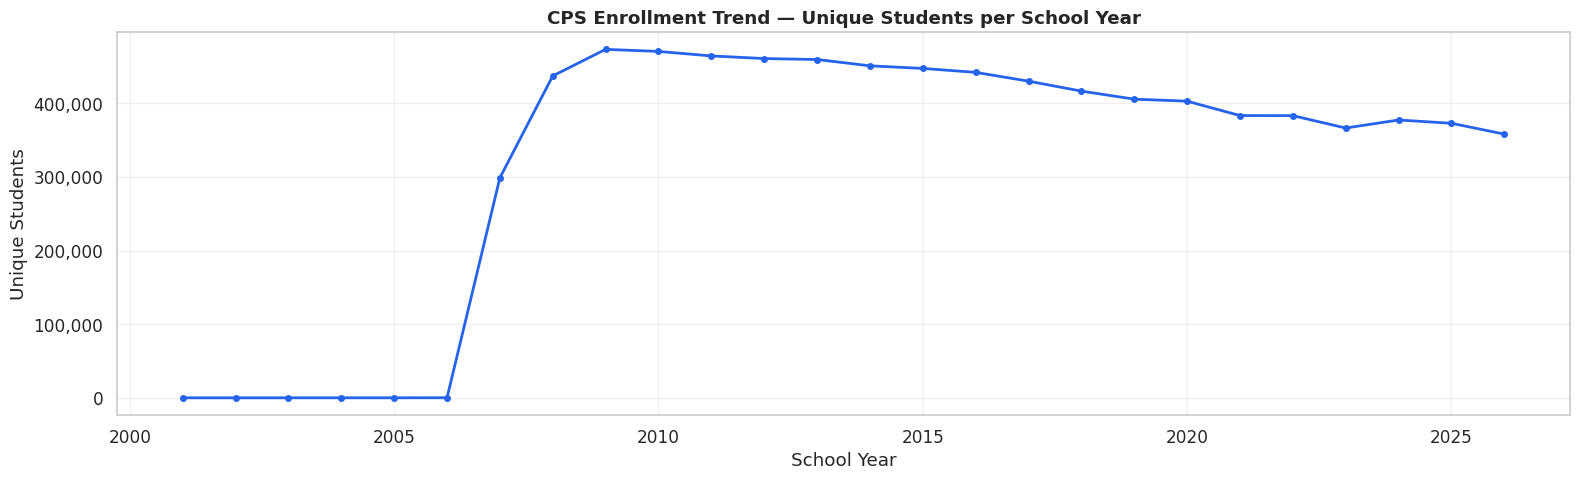

SynapseWidget(Synapse.DataFrame, 2adbed66-aa32-4f9e-a1e0-44483bc35259)

In [4]:
# ============================================================
# 2.2 — Enrollment trend by year
# ============================================================
yearly = (
    df.filter(F.col("IS_FUTURE_SCHOOL_YEAR") == False)
    .groupBy("SCHOOL_YEAR")
    .agg(
        F.countDistinct("STUDENT_KEY").alias("unique_students"),
        F.countDistinct("SCHOOL_KEY").alias("active_schools")
    )
    .orderBy("SCHOOL_YEAR")
)

pdf_yearly = yearly.toPandas()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(pdf_yearly["SCHOOL_YEAR"], pdf_yearly["unique_students"],
        marker="o", markersize=4, color="#2563EB", linewidth=2)
ax.set_title("CPS Enrollment Trend — Unique Students per School Year")
ax.set_xlabel("School Year")
ax.set_ylabel("Unique Students")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(yearly)

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 7, Finished, Available, Finished, False)

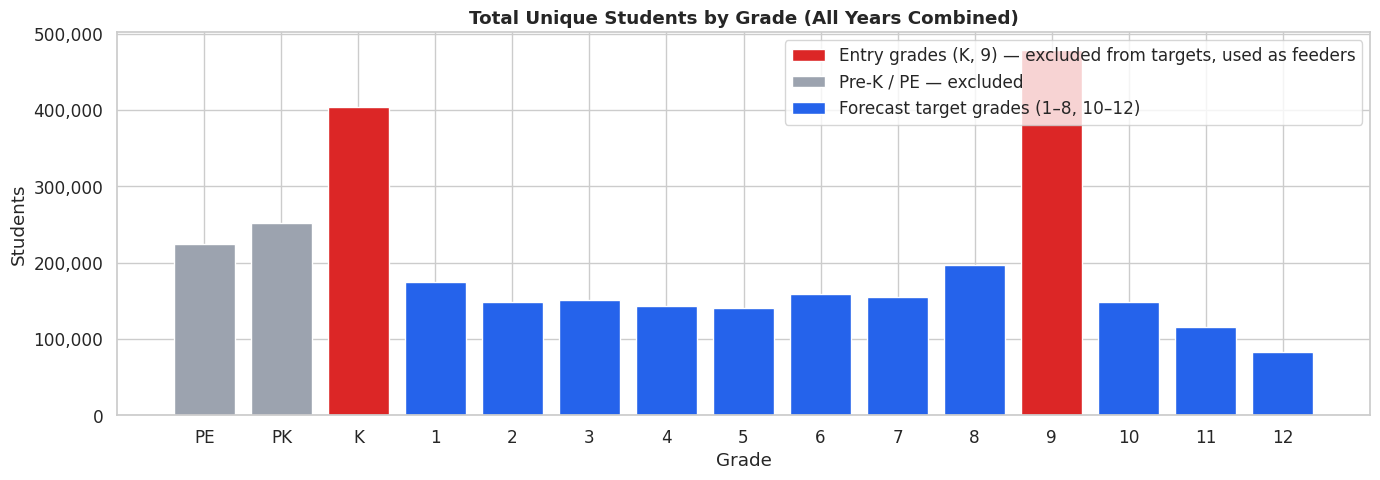

In [5]:
# ============================================================
# 2.3 — Grade distribution
# ============================================================
GRADE_ORDER = {
    "PE": 0, "PK": 1, "K": 2,
    "1": 3, "2": 4, "3": 5, "4": 6, "5": 7, "6": 8,
    "7": 9, "8": 10, "9": 11, "10": 12, "11": 13, "12": 14
}
grade_map_expr = F.create_map([F.lit(x) for pair in GRADE_ORDER.items() for x in pair])

grade_dist = (
    df.filter(F.col("IS_FUTURE_SCHOOL_YEAR") == False)
    .withColumn("GRADE", F.col("ENTRY_GRADE_LEVEL").cast("string"))
    .withColumn("grade_ord", grade_map_expr[F.col("GRADE")])
    .filter(F.col("grade_ord").isNotNull())
    .groupBy("GRADE", "grade_ord")
    .agg(F.countDistinct("STUDENT_KEY").alias("students"))
    .orderBy("grade_ord")
)

pdf_grade = grade_dist.toPandas()

colors = [
    "#DC2626" if g in ["K", "9"] else
    "#9CA3AF" if g in ["PE", "PK"] else
    "#2563EB"
    for g in pdf_grade["GRADE"]
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(pdf_grade["GRADE"], pdf_grade["students"], color=colors, edgecolor="white")
ax.set_title("Total Unique Students by Grade (All Years Combined)")
ax.set_xlabel("Grade")
ax.set_ylabel("Students")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#DC2626", label="Entry grades (K, 9) — excluded from targets, used as feeders"),
    Patch(facecolor="#9CA3AF", label="Pre-K / PE — excluded"),
    Patch(facecolor="#2563EB", label="Forecast target grades (1–8, 10–12)")
], loc="upper right")
plt.tight_layout()
plt.show()

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 8, Finished, Available, Finished, False)

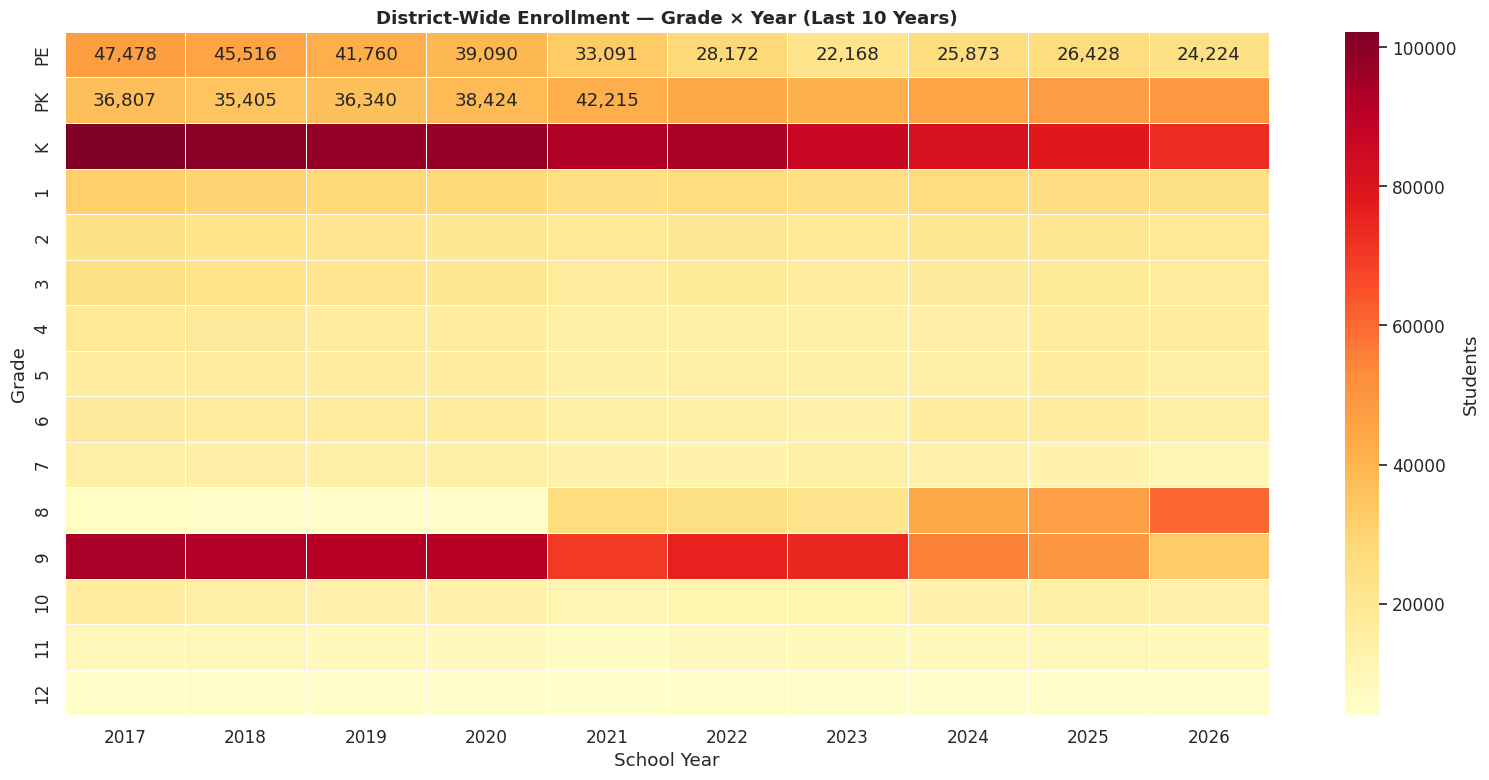

In [6]:
# ============================================================
# 2.4 — Grade × Year heatmap (last 10 years)
# ============================================================
grade_year = (
    df.filter(F.col("IS_FUTURE_SCHOOL_YEAR") == False)
    .withColumn("GRADE", F.col("ENTRY_GRADE_LEVEL").cast("string"))
    .withColumn("grade_ord", grade_map_expr[F.col("GRADE")])
    .filter(F.col("grade_ord").isNotNull())
    .groupBy("SCHOOL_YEAR", "GRADE", "grade_ord")
    .agg(F.countDistinct("STUDENT_KEY").alias("students"))
)

pdf_gy = grade_year.toPandas()
recent_years = sorted(pdf_gy["SCHOOL_YEAR"].unique())[-10:]
pdf_recent = pdf_gy[pdf_gy["SCHOOL_YEAR"].isin(recent_years)]

pivot = pdf_recent.pivot_table(index="GRADE", columns="SCHOOL_YEAR", values="students", fill_value=0)
grade_sort = [g for g in GRADE_ORDER.keys() if g in pivot.index]
pivot = pivot.reindex(grade_sort)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, fmt=",.0f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Students"})
ax.set_title("District-Wide Enrollment — Grade × Year (Last 10 Years)")
ax.set_xlabel("School Year")
ax.set_ylabel("Grade")
plt.tight_layout()
plt.show()

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 9, Finished, Available, Finished, False)

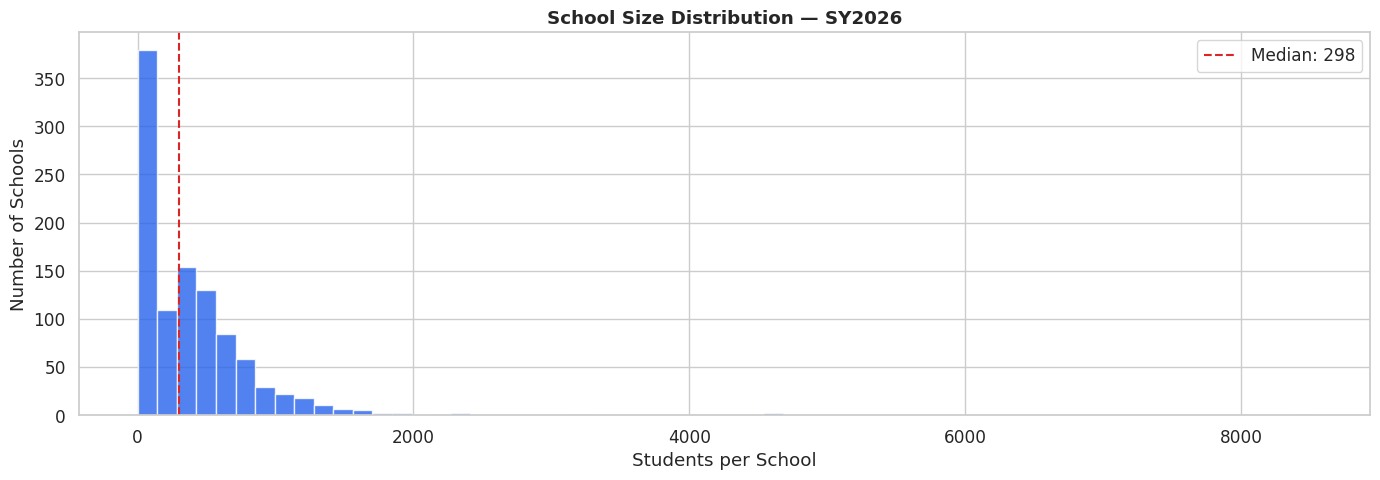

Schools: 1,016  |  Mean: 384  |  Median: 298  |  Min: 1  |  Max: 8513


In [7]:
# ============================================================
# 2.5 — School size distribution (latest year)
# ============================================================
max_year = df.filter(F.col("IS_FUTURE_SCHOOL_YEAR") == False).agg(F.max("SCHOOL_YEAR")).collect()[0][0]

pdf_sizes = (
    df.filter(F.col("SCHOOL_YEAR") == max_year)
    .groupBy("SCHOOL_KEY")
    .agg(F.countDistinct("STUDENT_KEY").alias("students"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(pdf_sizes["students"], bins=60, color="#2563EB", edgecolor="white", alpha=0.8)
ax.set_title(f"School Size Distribution — SY{max_year}")
ax.set_xlabel("Students per School")
ax.set_ylabel("Number of Schools")
ax.axvline(x=pdf_sizes["students"].median(), color="#DC2626", linestyle="--",
           label=f"Median: {pdf_sizes['students'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Schools: {len(pdf_sizes):,}  |  Mean: {pdf_sizes['students'].mean():.0f}  |  Median: {pdf_sizes['students'].median():.0f}  |  Min: {pdf_sizes['students'].min()}  |  Max: {pdf_sizes['students'].max()}")

---
## 3. Aggregate to School × Grade × Year

In [8]:
# ============================================================
# 3.1 — Aggregate: count distinct students per school×grade×year
# ALL grades kept (K and 9 needed for feeder features)
# ============================================================
df_agg = (
    df
    .filter(F.col("IS_FUTURE_SCHOOL_YEAR") == False)
    .withColumn("GRADE", F.col("ENTRY_GRADE_LEVEL").cast("string"))
    .withColumn("GRADE_NUMERIC", grade_map_expr[F.col("GRADE")])
    .filter(F.col("GRADE_NUMERIC").isNotNull())
    .groupBy("SCHOOL_KEY", "SCHOOL_YEAR", "GRADE", "GRADE_NUMERIC")
    .agg(F.countDistinct("STUDENT_KEY").alias("ENROLLMENT"))
)

print(f"✔ Aggregated: {df_agg.count():,} rows (school × grade × year)")
display(df_agg.orderBy("SCHOOL_KEY", "SCHOOL_YEAR", "GRADE_NUMERIC").limit(15))

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 10, Finished, Available, Finished, False)

✔ Aggregated: 125,804 rows (school × grade × year)


SynapseWidget(Synapse.DataFrame, 1c8ca583-8df4-485c-b73a-9de9a11e91ae)

---
## 4. Feature Engineering

### Keeping it simple — 4 features only

| Feature | What it is | Example |
|---|---|---|
| `SAME_GRADE_LAST_YEAR` | Same school, same grade, year-1 | Grade 8 enrollment last year |
| `SAME_GRADE_2YR_AGO` | Same school, same grade, year-2 | Grade 8 enrollment two years ago |
| `FEEDER_GRADE_LAST_YEAR` | Same school, grade-1, year-1 | Grade 7 last year → feeds into Grade 8 |
| `SCHOOL_TOTAL_ENROLLMENT` | All grades at this school, same year | Overall school size |

In [9]:
# ============================================================
# 4.1 — SAME_GRADE_LAST_YEAR and SAME_GRADE_2YR_AGO
# ============================================================
w_sg = Window.partitionBy("SCHOOL_KEY", "GRADE").orderBy("SCHOOL_YEAR")

df_feat = (
    df_agg
    .withColumn("SAME_GRADE_LAST_YEAR", F.lag("ENROLLMENT", 1).over(w_sg))
    .withColumn("SAME_GRADE_2YR_AGO",  F.lag("ENROLLMENT", 2).over(w_sg))
)

print("✔ Added: SAME_GRADE_LAST_YEAR, SAME_GRADE_2YR_AGO")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 11, Finished, Available, Finished, False)

✔ Added: SAME_GRADE_LAST_YEAR, SAME_GRADE_2YR_AGO


In [10]:
# ============================================================
# 4.2 — FEEDER_GRADE_LAST_YEAR
# Same school, grade G-1, year Y-1
#
# The key feature: students who will advance into this grade.
# Grade 1  ← K (last year)
# Grade 10 ← 9 (last year)
# Grade 8  ← 7 (last year), etc.
# ============================================================
feeder_lookup = (
    df_agg.select(
        F.col("SCHOOL_KEY").alias("_FK_SCHOOL"),
        F.col("GRADE_NUMERIC").alias("_FK_GRADE_NUM"),
        F.col("SCHOOL_YEAR").alias("_FK_YEAR"),
        F.col("ENROLLMENT").alias("FEEDER_GRADE_LAST_YEAR")
    )
)

df_feat = (
    df_feat.join(
        feeder_lookup,
        on=[
            df_feat["SCHOOL_KEY"] == feeder_lookup["_FK_SCHOOL"],
            df_feat["GRADE_NUMERIC"] == feeder_lookup["_FK_GRADE_NUM"] + 1,
            df_feat["SCHOOL_YEAR"] == feeder_lookup["_FK_YEAR"] + 1
        ],
        how="left"
    )
    .drop("_FK_SCHOOL", "_FK_GRADE_NUM", "_FK_YEAR")
)

print("✔ Added: FEEDER_GRADE_LAST_YEAR")
print("  Grade 1 feeder = K | Grade 10 feeder = 9")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 12, Finished, Available, Finished, False)

✔ Added: FEEDER_GRADE_LAST_YEAR
  Grade 1 feeder = K | Grade 10 feeder = 9


In [11]:
# ============================================================
# 4.3 — SCHOOL_TOTAL_ENROLLMENT (school size)
# ============================================================
school_totals = (
    df_agg
    .groupBy("SCHOOL_KEY", "SCHOOL_YEAR")
    .agg(F.sum("ENROLLMENT").alias("SCHOOL_TOTAL_ENROLLMENT"))
)

df_feat = df_feat.join(school_totals, on=["SCHOOL_KEY", "SCHOOL_YEAR"], how="left")

print("✔ Added: SCHOOL_TOTAL_ENROLLMENT")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 13, Finished, Available, Finished, False)

✔ Added: SCHOOL_TOTAL_ENROLLMENT


In [12]:
# ============================================================
# 4.4 — Placeholder for school name
# ============================================================
# UNCOMMENT when dim_school is available:
#
# dim_school = spark.read.table("dim_school").select(
#     "SCHOOL_KEY", "SCHOOL_NAME", "SCHOOL_TYPE", "COMMUNITY_AREA"
# )
# df_feat = df_feat.join(dim_school, on="SCHOOL_KEY", how="left")

print("⏳ School name: awaiting dim_school table. Using SCHOOL_KEY for now.")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 14, Finished, Available, Finished, False)

⏳ School name: awaiting dim_school table. Using SCHOOL_KEY for now.


---
## 5. Build Final Feature Table

In [13]:
# ============================================================
# 5.1 — Filter to target grades only + require history
# ============================================================
TARGET_GRADES = ["1", "2", "3", "4", "5", "6", "7", "8", "10", "11", "12"]

df_final = (
    df_feat
    .filter(F.col("GRADE").isin(TARGET_GRADES))
    .filter(F.col("SAME_GRADE_LAST_YEAR").isNotNull())
)

print(f"Target grades: {TARGET_GRADES}")
print(f"Rows with history: {df_final.count():,}")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 15, Finished, Available, Finished, False)

Target grades: ['1', '2', '3', '4', '5', '6', '7', '8', '10', '11', '12']
Rows with history: 85,338


In [14]:
# ============================================================
# 5.2 — Select final columns
# ============================================================
final_columns = [
    # Identifiers
    "SCHOOL_KEY",
    "GRADE",
    "GRADE_NUMERIC",
    "SCHOOL_YEAR",

    # TARGET
    "ENROLLMENT",

    # Features
    "SAME_GRADE_LAST_YEAR",
    "SAME_GRADE_2YR_AGO",
    "FEEDER_GRADE_LAST_YEAR",
    "SCHOOL_TOTAL_ENROLLMENT"
]

df_final = df_final.select(final_columns)

print(f"Final feature table: {df_final.count():,} rows × {len(final_columns)} columns\n")
for i, c in enumerate(final_columns, 1):
    role = "TARGET" if c == "ENROLLMENT" else "ID" if c in ["SCHOOL_KEY", "GRADE", "GRADE_NUMERIC", "SCHOOL_YEAR"] else "FEATURE"
    print(f"  {i:2d}. [{role:7s}] {c}")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 16, Finished, Available, Finished, False)

Final feature table: 85,338 rows × 9 columns

   1. [ID     ] SCHOOL_KEY
   2. [ID     ] GRADE
   3. [ID     ] GRADE_NUMERIC
   4. [ID     ] SCHOOL_YEAR
   5. [TARGET ] ENROLLMENT
   6. [FEATURE] SAME_GRADE_LAST_YEAR
   7. [FEATURE] SAME_GRADE_2YR_AGO
   8. [FEATURE] FEEDER_GRADE_LAST_YEAR
   9. [FEATURE] SCHOOL_TOTAL_ENROLLMENT


In [15]:
# ============================================================
# 5.3 — Preview: one school across grades and years
# Verify the feeder logic visually.
# ============================================================
sample_school = df_final.select("SCHOOL_KEY").distinct().limit(1).collect()[0][0]

print(f"Sample school: {sample_school}")
print("Check: FEEDER_GRADE_LAST_YEAR for Grade 8 should = ENROLLMENT of Grade 7 from prior year\n")

display(
    df_final
    .filter(F.col("SCHOOL_KEY") == sample_school)
    .orderBy("SCHOOL_YEAR", "GRADE_NUMERIC")
    .limit(30)
)

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 17, Finished, Available, Finished, False)

Sample school: 1
Check: FEEDER_GRADE_LAST_YEAR for Grade 8 should = ENROLLMENT of Grade 7 from prior year



SynapseWidget(Synapse.DataFrame, 08dd73bd-5a45-4ba2-86bf-aa7939d7bd4a)

In [16]:
# ============================================================
# 5.4 — Feature fill rates
# ============================================================
total = df_final.count()
feature_cols = ["SAME_GRADE_LAST_YEAR", "SAME_GRADE_2YR_AGO",
                "FEEDER_GRADE_LAST_YEAR", "SCHOOL_TOTAL_ENROLLMENT"]

print(f"Feature fill rates ({total:,} rows):\n")
for c in feature_cols:
    non_null = df_final.filter(F.col(c).isNotNull()).count()
    rate = round(non_null / total * 100, 1)
    status = "✔" if rate > 80 else "⚠"
    print(f"  {status} {c:30s}: {rate}%")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 18, Finished, Available, Finished, False)

Feature fill rates (85,338 rows):

  ✔ SAME_GRADE_LAST_YEAR          : 100.0%
  ✔ SAME_GRADE_2YR_AGO            : 92.5%
  ✔ FEEDER_GRADE_LAST_YEAR        : 95.8%
  ✔ SCHOOL_TOTAL_ENROLLMENT       : 100.0%


---
## 6. Write to Lakehouse

In [17]:
FEATURE_TABLE_NAME = "ml_enrollment_feature_table"

df_final.write.mode("overwrite").saveAsTable(FEATURE_TABLE_NAME)

verify = spark.read.table(FEATURE_TABLE_NAME)
print(f"✔ Written: '{FEATURE_TABLE_NAME}'")
print(f"  Rows   : {verify.count():,}")
print(f"  Columns: {len(verify.columns)}")
print(f"  Years  : {verify.agg(F.min('SCHOOL_YEAR')).collect()[0][0]} – {verify.agg(F.max('SCHOOL_YEAR')).collect()[0][0]}")
print(f"  Grades : {sorted([r[0] for r in verify.select('GRADE').distinct().collect()])}")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 19, Finished, Available, Finished, False)

✔ Written: 'ml_enrollment_feature_table'
  Rows   : 85,338
  Columns: 9
  Years  : 2005 – 2026
  Grades : ['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8']


---
## 7. Ready for GBT

| Column | Role |
|---|---|
| `SCHOOL_KEY` | School identifier |
| `GRADE` | Grade (1–8, 10–12) |
| `SCHOOL_YEAR` | Year |
| `ENROLLMENT` | **TARGET** |
| `SAME_GRADE_LAST_YEAR` | Feature — same grade enrollment last year |
| `SAME_GRADE_2YR_AGO` | Feature — same grade enrollment 2 years ago |
| `FEEDER_GRADE_LAST_YEAR` | Feature — grade G-1 enrollment last year (advancing cohort) |
| `SCHOOL_TOTAL_ENROLLMENT` | Feature — total school size |

In [18]:
print("""
Next step — GBT training:

  df = spark.read.table("ml_enrollment_feature_table")

  # Time-based split (never random)
  max_year = df.agg(F.max("SCHOOL_YEAR")).collect()[0][0]
  train = df.filter(F.col("SCHOOL_YEAR") < max_year)
  test  = df.filter(F.col("SCHOOL_YEAR") == max_year)

  features = [
      "SAME_GRADE_LAST_YEAR",
      "SAME_GRADE_2YR_AGO",
      "FEEDER_GRADE_LAST_YEAR",
      "SCHOOL_TOTAL_ENROLLMENT",
      "GRADE_NUMERIC"
  ]

  target = "ENROLLMENT"
""")

StatementMeta(, 741204d1-f9f4-499d-8e98-71b684bb8787, 20, Finished, Available, Finished, False)


Next step — GBT training:

  df = spark.read.table("ml_enrollment_feature_table")

  # Time-based split (never random)
  max_year = df.agg(F.max("SCHOOL_YEAR")).collect()[0][0]
  train = df.filter(F.col("SCHOOL_YEAR") < max_year)
  test  = df.filter(F.col("SCHOOL_YEAR") == max_year)

  features = [
      "SAME_GRADE_LAST_YEAR",
      "SAME_GRADE_2YR_AGO",
      "FEEDER_GRADE_LAST_YEAR",
      "SCHOOL_TOTAL_ENROLLMENT",
      "GRADE_NUMERIC"
  ]

  target = "ENROLLMENT"

